In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('engine_fault_detection_dataset.csv')

# Remove 'ID' column if it exists
if 'ID' in df.columns:
    df.drop(columns=['ID'], inplace=True)
    print("Removed 'ID' column.")

# Check for null values
print("\nNull values before handling:")
display(df.isnull().sum())


Null values before handling:


,0
Vibration_Amplitude,0
RMS_Vibration,0
Vibration_Frequency,0
Surface_Temperature,0
Exhaust_Temperature,0
Acoustic_dB,0
Acoustic_Frequency,0
Intake_Pressure,0
Exhaust_Pressure,0
Frequency_Band_Energy,0


The previous output shows that there are no null values in the dataset. Now, let's split the data into training and testing sets, separating features (X) from the target variable (y), `Engine_Condition`.

In [14]:
# Separate features (X) and target (y)
X = df.drop(columns=['Engine_Condition'])
y = df['Engine_Condition']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

display(X_train.head())

X_train shape: (8000, 11)
X_test shape: (2000, 11)
y_train shape: (8000,)
y_test shape: (2000,)


,Vibration_Amplitude,RMS_Vibration,Vibration_Frequency,Surface_Temperature,Exhaust_Temperature,Acoustic_dB,Acoustic_Frequency,Intake_Pressure,Exhaust_Pressure,Frequency_Band_Energy,Amplitude_Mean
5497,8.901106,0.180950,565.653279,83.611634,215.638888,107.474663,4444.229715,115.777141,96.287653,0.573612,0.049592
5724,1.390172,4.614496,1150.134536,69.292948,431.116824,111.563255,1697.048948,93.550850,97.565237,0.756981,0.461253
4066,1.346956,4.822522,290.642873,90.774905,200.037438,114.695462,1386.127445,104.870737,96.850244,0.477707,0.325053
6743,8.632254,4.549909,1490.949134,67.704489,468.825086,101.539438,823.418530,117.435590,95.616098,0.212447,0.311906
9525,4.660781,3.719127,944.310618,32.974600,481.055248,116.329910,2085.781315,99.090310,90.424936,0.568590,0.385344


Logistic Regression with class_weight='balanced' - Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.34      0.43      1193
           1       0.33      0.34      0.33       607
           2       0.10      0.37      0.16       200

    accuracy                           0.34      2000
   macro avg       0.35      0.35      0.31      2000
weighted avg       0.48      0.34      0.38      2000



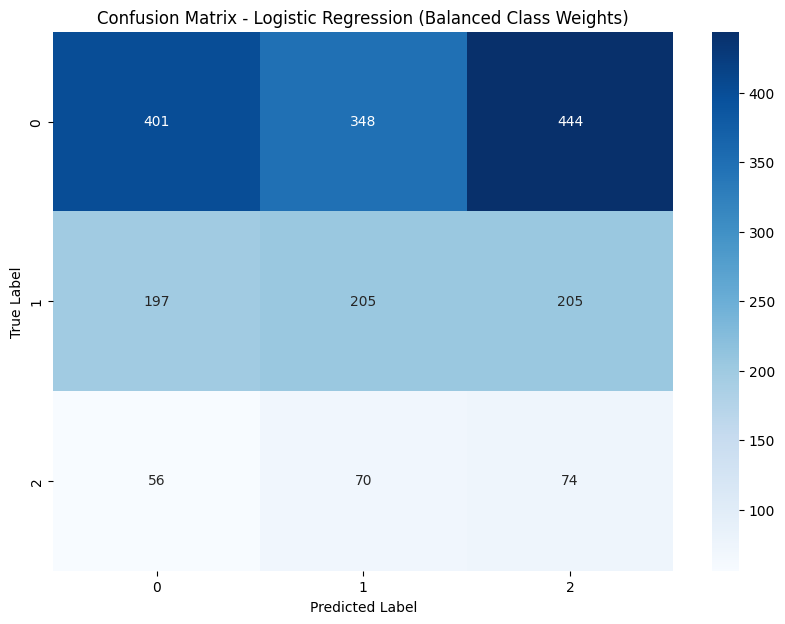

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.multiclass import OneVsRestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Logistic Regression with class_weight='balanced' to handle imbalance
# and wrap it in OneVsRestClassifier for explicit multi-class handling
classifier = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42, max_iter=1000, class_weight='balanced'))

# Train the model on the scaled training data
classifier.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_lr = classifier.predict(X_test_scaled)

# Display Classification Report
# zero_division=0 ensures that precision/recall/f1 are explicitly 0.0 when no true samples or predictions are made
print("Logistic Regression with class_weight='balanced' - Classification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

# Display Confusion Matrix
plt.figure(figsize=(10, 7))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (Balanced Class Weights)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

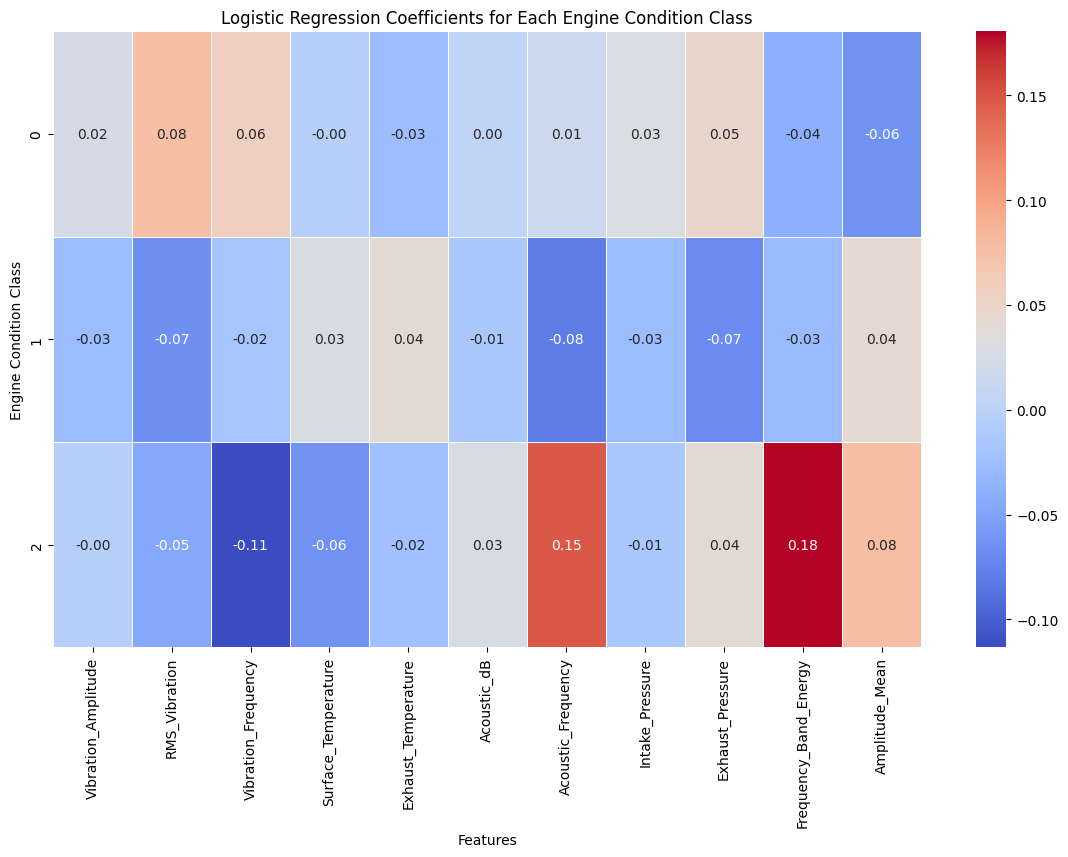

Interpretation of Coefficients:
- Positive coefficients indicate that an increase in the feature's value increases the log-odds of that class (vs. others).
- Negative coefficients indicate that an increase in the feature's value decreases the log-odds of that class.
- The magnitude of the coefficient indicates the strength of the relationship.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract coefficients for each class
# classifier.estimators_ holds the individual LogisticRegression models for each class in OneVsRestClassifier
coefficients = [est.coef_[0] for est in classifier.estimators_]
coefficient_df = pd.DataFrame(coefficients, columns=X_train_scaled.columns)

# Add class labels to the DataFrame
class_labels = y.unique()
class_labels.sort() # Ensure consistent order if not already sorted
coefficient_df['Class'] = class_labels
coefficient_df = coefficient_df.set_index('Class')

plt.figure(figsize=(14, 8))
sns.heatmap(coefficient_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Logistic Regression Coefficients for Each Engine Condition Class')
plt.xlabel('Features')
plt.ylabel('Engine Condition Class')
plt.show()

print("Interpretation of Coefficients:")
print("- Positive coefficients indicate that an increase in the feature's value increases the log-odds of that class (vs. others).")
print("- Negative coefficients indicate that an increase in the feature's value decreases the log-odds of that class.")
print("- The magnitude of the coefficient indicates the strength of the relationship.")